
# Bayesian Hierarchical ARX Hurdle Model for Gravity Migration

#### Brouillon (daté du 26 mars) pour présenter la méthode générale, les paramètres, la hiérarchie, l'hétéroscédasticité, quelques résultats. 
### Une version propre sera disponible la semaine prochaine, qui s'intègrera au rapport.




**A. Hurdle (Logit)** : 
$\text{logit}(P(\text{flow}>0)) = \alpha_d + X_h \beta_h + \beta_{lag} \text{is\_mig\_lag}$

**X_h**= (frontière_commune_ij, log(distance_ij) ).  
**B. Volume (ARX)** : 
$$\log(\text{flow}) \sim \mathcal{N}(\mu_{d,t} + \phi_d (\text{lag} - \mu_{d,t-1}), \sigma_d)$$
$$\mu_{d,t} = \alpha_{V,d} + X \beta_{\text{grav}} + \beta_{\text{gdp}} \log(\text{gdpcap\_o}) + \beta_{\text{rich}} \text{is\_rich\_o}$$

**X**: toutes les variables du modèle de gravité de Welch&raftery.  
**is_rich_o:** est ce que le pays de départ dépasse le seuil de 18,000$ de PIB/tête (seuil détecter par Random Forest)  


# Hamiltonian Monte Carlo: 
(absolument crucial, descendre une pente est bien plus rapide à converger qu'un Metropolis aveugle)

- Le paysage énergétique est un espace de paramètres postériors, chaque position est un vecteur de paramètres (de dimension 90 000 environ, voir partie Paramètres ci-dessous). Si on travaille en -log-vraisemblance: les puits sont les zones de fortes probabilités. 

- À chaque itération $s$ (de 1 à iter_sampling): Impulsion aléatoire, puis la fin du mouvement régit par les équations de Hamilton jusqu'à la position x. 

- A la position x, Stan possède un set de paramètres. Il calcule alors mécaniquement :$$\mu_{d,t}^{(s)} = \alpha_{V,d}^{(s)} + X \beta_{\text{grav}}^{(s)} + \beta_{\text{gdp}}^{(s)} \log(\text{gdpcap\_o}) + \beta_{\text{rich}}^{(s)} \text{is\_rich\_o} $$


Modèle hiérarchique hétérosced: (dans *transformed parameters*)

$\alpha_{V,d} = \mu_{intercept} + \tau_{\mu} \times \mu_{raw}[d]$ *(intercept: moyenne sur le meme cluster)*

$\phi_d = \tanh(\phi_{global\_raw} + \tau_{\phi} \times \phi_{raw}[d])$ *(raw: chaque couloir possède son raw unique, son ADN, générée d'un prior)*  
Rq: ne pas laisser Stan tirer de mu_d ~ normal(mu_intercept, tau_mu) car il resterait bloqué si tau_mu proche de zéro )

$\sigma_d = \sigma_{cluster}[continent] \times \exp(\tau_{\sigma} \times \sigma_{raw}[d])$

Stan prend les raw tirés du bruit et les multiplie par les $\tau$ pour construire l'état de chaque couloir : $\alpha_{V,d}^{(s)}$, $\phi_d^{(s)}$ et $\sigma_d^{(s)}$.
Il assemble tout ça avec les variables géoécononomiques ($X$, PIB, etc.) pour calculer le $\mu_{d,t}^{(s)}$.


Puis, il utilise cette valeur pour évaluer la distance par rapport aux vrais flux via la loi Volume:
$$\log(\text{flow}) \sim \mathcal{N}(\mu_{d,t}^{(s)} + \phi_d^{(s)} (\text{lag} - \mu_{d,t-1}^{(s)}), \sigma_d^{(s)}) $$

L'acceptation (Metropolis-Hastings) à la fin du mouvement: Stan vérifie si l'énergie totale a été conservée. Il applique la règle d'acceptation :
$$P(\text{acceptation}) = \min(1, \exp(-\Delta H))$$
(isomorphisme entre conservation de l'énergie et maximisation de la proba a posteriori plutôt, càd vraisemblance + priors. C'est un compromis entre ce que disent les données et les priors)

Si la nouvelle position est cohérente avec les données ($\Delta H =0$) , il l'accepte et inscrit les paramètres dans des matrices.  
Sinon, il rejette la proposition et reste sur la valeur précédente.

**paramètres globaux:** vecteurs de 1200 composantes à la fin du sampling
- mu : matrice qui contient les log(flow), 1200* nombre de couloirs
- sigma_cluster : dimension 1200x6
- beta_grav: 1200x20 (20 variables explicatives)
- effets dyadiques: matrices de 1200*nombres de couloirs



**C. Variance (Geo)** : 
$\sigma_d \sim \text{HalfNormal}(\sigma_{\text{cluster}}[\text{continent\_origine}[d]])$ *(alternative à InverseGamma)*


# Prédiction : 

une fois stocké toutes les matrices de paramètres, numpy prend la relève et calcule bêtement toutes les formules pour chaque itération
(par ex $$\mu_{d,t}^{(1)} = \alpha_d^{(1)} + X \beta^{(1)}$$ pour l'itération s=1). Il fait ça pour les 1200 itérations, pour chaque couloir. 

**On a donc chains * iter / thin * dyades prédictions.**  
**On prend la médiane de ces prédictions pour chaque couloir, pour minimiser l'erreur MAE.**

# MÉTHODOLOGIE 
*(pour rapport ou annexe)*

1) Couplage entre bayésien & Machine Learning (Partie ARX et Variance Géo).  
Ce modèle bayésien intègre les découvertes faites par le Random Forest :
- Saut brutal de migration autour de 18 000 $ de PIB/hab. 
  Encodé par la variable indicatrice 'is_rich_o' 
- Interaction 'log_D_ij * LB_ij' (distance * frontière commune) 
  dont l'importance a été découverte par un PDP 2D du Random forest, et prouvée par régression linéaire 
- Correction des résidus : La cartographie des erreurs des XGBoost & RF montrait une incertitude 
  systématique (sous/sur-estimation) en Afrique, et un peu en Asie/Amerique latine. L'hétéroscédasticité 
  géographique modélise cette variance propre à chaque continent (à affiner par zone géo plus précise?)


2) Gestion des zéros (partie Hurdle). 
Le problème: il y a beaucoup de flux nuls, et on ne peut ni les enlever de l'analyse, ni faire log(x+1) (scientifiquement mauvais)
Forcer un pic à zéro pour loi Normale (qui ne sait faire que une cloche, et pas une cloche + un pic à zéro) fait diverger 
la variance et les chaines de Markov. 
Le modèle Hurdle: regression logistique (Bernoulli); si et seulement si le couloir est ouvert (>0) => équation de gravité ARX. 
Si non (flux=0) STAN s'arrête là et prédit 0 migrant (dans la phase de prédiction)



3) intuition physique de STAN (Hamiltonian Monte Carlo). 
Contrairement aux auteurs qui utilisaient le Gibbs sampling via JAGS, Stan utilise HMC. 
 HMC utilise la mécanique hamiltonienne pour explorer le paysage des posteriors bayésiens, (trajectoire guidée par lmes équations de Hamilton)
avec une étape d'acceptation Metropolis-Hastings à la fin selon $$P(\text{acceptation}) = \min(1, \exp(-\Delta H))$$ 
pour corriger les erreurs numériques sur la conservation de l'énergie ($$\Delta H =0$$) liées à la discrétisation de temporelle. 


Une exploration entière par Metropolis (marche aléatoire) aurait été inefficace et incroyablement lente pour autant de paramètres

4) Stabilité géométrique.  
Pour éviter que l'algorithme ne se coince (entonnoir), au lieu d'échantillonner 
directement α_d ~ N(μ, τ), on échantillonne un bruit pur ε ~ N(0,1), puis on calcule 
 α_d = μ + τ·ε. Cela détruit les corrélations pathologiques durant le HMC 

5) Approche dyadique.  
Mon modèle est purement "Dyadique" contrairement à celui de Ishagh (Inflow/Outflow). Ce code modélise chaque couloir de migration.  
On pourra comparer les deux approches in fine. 

6) Évaluation Out-Of-Sample.  
Le modèle est entraîné sur la période 1990-2010 et testé en prédiction pure sur 2015. 
Pour évaluer la qualité de la prédiction, on retient la MAE (Erreur absolue en nombre d'humains réels) et le MAPE comme Welch&raftery pour pouvoir comparer nos résultats   
(**attention:** Welch&raftery divisent par y+1 leur erreur MAPE pour éviter la division par zéro, ce qu'on fait donc aussi)

# Commentaires de résultats
**Médiane vs Espérance (Le problème des 25M) :**  
Le modèle est évalué en MAE. L'espérance $exp(\mu + \sigma^2/2)$ minimise la MSE mais donne des prédictions délirantes quand la variance explose. (Stan gonfle la variance future avec l'inflation $1+\phi^2$ car il y a l'incertitude passée PLUS(+) l'incertitude nouvelle à considérer).  
Un gros sigma donne vite une prédiction max absurde à 25 millions de migrants pour la route MEX-USA par ex. On utilise donc la médiane $exp(\mu)$ comme minimiseur naturel de la norme L1 (MAE). 

#### De toute façon, le choix le plus "économétrique (pour la décision publique)" pour des flux migratoires, c'est de s'intéresser à l'erreur en nombre de migrants (pas en carré de migrants).


**Métrique ROC :**  
Pour le seuil d'ouverture Hurdle, on utilise la courbe ROC plutôt que l'Accuracy pure. Le choix est arbitraire et les deux cas reviennent au même à 0,03% près de précision: en effet il n'y a pas de classe majoritaire dans nos données (49% de zéros). 

**Coverage & IC :**    
L'hétéroscédasticité marche super bien ici. Pour un couloir européen stable, le modèle coupe les 2.5% extrêmes et donne un IC étroit (+/- 30%). Pour un couloir asiatique instable, ça s'écarte beaucoup plus (jusqu'à +150% de largeur). Le but ultime c'est que la vraie valeur tombe dans l'IC dans 95% des cas.

**Comparaison Welch & Raftery :**    
En plus de la MAE et du Log-MAE (parfait pour les ordres de grandeurs), on suit le WMAPE et le "MAPE+1" (Eq 4 du papier de Welch) pour pouvoir faire un vrai benchmark face à eux sans que la division par zéro des petits couloirs ne fasse crasher le calcul.



# Paramètres: 

Partie Hurdle ($D_h$) : Un paramètre alpha_raw par dyade. Cela fait 190 * 189 dimensions. 
Partie Volume ($D_v$) : mu_raw (l'intercepte du volume), phi_raw (l'inertie AR1 propre au couloir) et sigma_raw par dyade. Environ 50% des dyades ont du volume, donc 0.5 * 190 * 189 * 3 dimensions environ. 

- Gravité & Hurdle : Les vecteurs $\beta_{h}$ (3) et $\beta_{grav}$ (~20).
- Hyper-paramètres : Les moyennes et variances globales (mu_intercept, sigma_global, phi_global, tau_alpha, tau_mu, tau_sigma, tau_phi).
- Clusters : Les variances par continent sigma_cluster (6 dimensions).


# Davantages de commentaires des résultats et de la méthode au fil du notebook, et en commentaire dans les cellules de code. 

paramètres propres à chaque pays.  
ESS bulk= effective sample size. cf cours monte carlo methods  


In [1]:
# Installation des bibliothèques non classiqus
#!pip install pycountry_convert arviz cmdstanpy

# compilation de Stan
#import cmdstanpy
#cmdstanpy.install_cmdstan()

# stratégie à faire le 27 mars: 

### enrichissement du Hurdle en variables;
 rechercher les "cygnes noirs" (les derniers 3,8% de precision du Hurdle).  

variables retenues: (le but n'est pas de mettre TOUTES les variables de gravité. Le Hurdle s'intéresse à l'*existence* du couloir, pas à son *volume*. Les variables les plus pertinentes: OL_ij et COL_ij (passé historique colonial et langue officielle commune) ; log_pop_d et log_pop_o (si les deux pays sont massifs, alors il y a certainement un flux) ) ; log_gdp_d et IMR (indice de richesse du pays d'arrivée).   

### beta_lag_global à passer en continental; 

et montrer que chaque continent a un coeff très différent pour valider l'approche. 



In [ ]:

import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import pycountry_convert as pc
from cmdstanpy import CmdStanModel
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve  

warnings.filterwarnings('ignore')
np.random.seed(42)




# Chargement & filtrage pays




DATA_PATH = "../data/data_final/DF_GRAVITY_sans_NaN.csv"
df_main = pd.read_csv(DATA_PATH)

"""
# Tous les pays
  
df = df_main[df_main['orig'] != df_main['dest']].copy()
df = df.sort_values(['orig', 'dest', 'year']).reset_index(drop=True)
print(f"Lignes chargées : {len(df)} | Pays uniques : {df['orig'].nunique()}")
"""


#  Décommenter pour sanity-check ou simulation plus globale 


"""

# 70 pays 


PAYS_NORD = [
    'FRA', 'USA', 'ESP', 'CAN', 'DEU', 'GBR', 'ITA', 'AUS', 'CHE', 
    'JPN', 'SWE', 'NLD', 'BEL', 'NOR', 'AUT', 'PRT', 'NZL', 'DNK', 'FIN', 'IRL'
]

PAYS_AFRIQUE = [
    'DZA', 'RWA', 'ZAF', 'NER', 'NGA', 'COD', 'SOM', 'MAR', 'EGY', 
    'SEN', 'ETH', 'TUN', 'MLI', 'CIV', 'GHA', 'AGO', 'KEN', 'SDN', 'LBY', 'CMR'
]

PAYS_AMLAT = [
    'HTI', 'MEX', 'VEN', 'COL', 'BRA', 'SLV', 
    'ARG', 'CHL', 'PER', 'CUB', 'GTM', 'HND', 'ECU', 'DOM', 'CRI'
]

PAYS_ASIE = [
    'MMR', 'IND', 'CHN', 'SYR', 'AFG', 'PAK', 'PHL', 'BGD', 
    'VNM', 'TUR', 'IDN', 'THA', 'IRQ', 'YEM', 'LBN', 'SAU', 'ARE', 'KAZ', 'UZB', 'KOR'
]
"""

# 140 pays 

#"""



PAYS_NORD = [
    'FRA', 'USA', 'ESP', 'CAN', 'DEU', 'GBR', 'ITA', 'AUS', 'CHE', 
    'JPN', 'SWE', 'NLD', 'BEL', 'NOR', 'AUT', 'PRT', 'NZL', 'DNK', 'FIN', 'IRL',
    'POL', 'CZE', 'GRC', 'HUN', 'ROU', 'BGR', 'HRV', 'SVK', 'SVN', 'EST',
    'LVA', 'LTU', 'ISL', 'CYP', 'MLT', 'LUX', 'SRB', 'BIH', 'ALB', 'MKD'
]


PAYS_AFRIQUE = [
    'DZA', 'RWA', 'ZAF', 'NER', 'NGA', 'COD', 'SOM', 'MAR', 'EGY', 
    'SEN', 'ETH', 'TUN', 'MLI', 'CIV', 'GHA', 'AGO', 'KEN', 'SDN', 'LBY', 'CMR',
    'UGA', 'TZA', 'MOZ', 'ZMB', 'ZWE', 'TCD', 'BFA', 'GIN', 'MDG', 'MWI',
    'BDI', 'MRT', 'NAM', 'BWA', 'GAB'
]


PAYS_AMLAT = [
    'HTI', 'MEX', 'VEN', 'COL', 'BRA', 'SLV', 'ARG', 'CHL', 'PER', 'CUB', 
    'GTM', 'HND', 'ECU', 'DOM', 'CRI', 'BOL', 'PRY', 'URY', 'NIC', 'PAN',
    'JAM', 'TTO', 'GUY', 'SUR', 'BLZ'
]


PAYS_ASIE = [
    'MMR', 'IND', 'CHN', 'SYR', 'AFG', 'PAK', 'PHL', 'BGD', 'VNM', 'TUR', 
    'IDN', 'THA', 'IRQ', 'YEM', 'LBN', 'SAU', 'ARE', 'KAZ', 'UZB', 'KOR',
    'IRN', 'ISR', 'JOR', 'MYS', 'SGP', 'LKA', 'NPL', 'KHM', 'OMN', 'QAT',
    'KWT', 'BHR', 'LAO', 'MNG', 'TJK', 'KGZ', 'TKM', 'GEO', 'ARM', 'AZE'
]

#"""

#"""
# 110 Pays 


PAYS_NORD = [
    'FRA', 'USA', 'ESP', 'CAN', 'DEU', 'GBR', 'ITA', 'AUS', 'CHE', 
    'JPN', 'SWE', 'NLD', 'BEL', 'NOR', 'AUT', 'PRT', 'NZL', 'DNK', 'FIN', 'IRL',
    'POL', 'CZE', 'GRC', 'HUN', 'ROU', 'BGR', 'HRV', 'SVK', 'SVN', 'EST'
]


PAYS_AFRIQUE = [
    'DZA', 'RWA', 'ZAF', 'NER', 'NGA', 'COD', 'SOM', 'MAR', 'EGY', 
    'SEN', 'ETH', 'TUN', 'MLI', 'CIV', 'GHA', 'AGO', 'KEN', 'SDN', 'LBY', 'CMR',
    'UGA', 'TZA', 'MOZ', 'ZMB', 'ZWE', 'TCD', 'BFA', 'GIN', 'MDG', 'MWI'
]


PAYS_AMLAT = [
    'HTI', 'MEX', 'VEN', 'COL', 'BRA', 'SLV', 'ARG', 'CHL', 'PER', 'CUB', 
    'GTM', 'HND', 'ECU', 'DOM', 'CRI',
    'BOL', 'PRY', 'URY', 'NIC', 'PAN'
]


PAYS_ASIE = [
    'MMR', 'IND', 'CHN', 'SYR', 'AFG', 'PAK', 'PHL', 'BGD', 'VNM', 'TUR', 
    'IDN', 'THA', 'IRQ', 'YEM', 'LBN', 'SAU', 'ARE', 'KAZ', 'UZB', 'KOR',
    'IRN', 'ISR', 'JOR', 'MYS', 'SGP', 'LKA', 'NPL', 'KHM', 'OMN', 'QAT'
]

#"""

"""
# 66 pays (production)
PAYS_NORD    = ['FRA', 'USA', 'ESP', 'CAN', 'DEU', 'GBR', 'ITA', 'AUS', 'CHE',
                'JPN', 'KOR', 'NLD', 'SWE', 'BEL', 'AUT', 'POL', 'NZL']
PAYS_AFRIQUE = ['DZA', 'RWA', 'ZAF', 'NER', 'NGA', 'COD', 'SOM', 'MAR', 'EGY',
               'SEN', 'CIV', 'KEN', 'ETH', 'GHA', 'AGO', 'TUN', 'CMR']
PAYS_AMLAT   = ['HTI', 'MEX', 'VEN', 'COL', 'BRA', 'SLV',
                'ARG', 'CHL', 'PER', 'ECU', 'CUB', 'DOM', 'GTM', 'BOL', 'URY']
PAYS_ASIE    = ['MMR', 'IND', 'CHN', 'SYR', 'AFG', 'PAK', 'PHL', 'BGD',
                 'VNM', 'THA', 'IDN', 'MYS', 'IRN', 'SAU', 'TUR', 'IRQ', 'ARE']
"""

#"""
PAYS_TEST = PAYS_NORD + PAYS_AFRIQUE + PAYS_AMLAT + PAYS_ASIE



df = df_main[
    df_main['orig'].isin(PAYS_TEST) &
    df_main['dest'].isin(PAYS_TEST) &
    (df_main['orig'] != df_main['dest'])
].copy()
df = df.sort_values(['orig', 'dest', 'year']).reset_index(drop=True)
#"""



/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Clustering géographique




def get_continent_id(iso3_code):
    try:
        iso2 = pc.country_alpha3_to_country_alpha2(iso3_code)
        continent = pc.country_alpha2_to_continent_code(iso2)
        return {'EU': 1, 'NA': 2, 'AF': 3, 'SA': 4, 'AS': 5, 'OC': 6}.get(continent, 7)
    except Exception:
        return 7

df['continent_orig'] = df['orig'].apply(get_continent_id)
K_clusters = 6




In [4]:
# Features, lags et split train/test




df['is_migration'] = (df['flow'] > 0).astype(int)
df['log_flow']     = np.where(df['flow'] > 0, np.log(df['flow']), np.nan)

SEUIL_LOG_GDP       = 2.9
df['is_rich_o']     = (df['log_gdpcap_o_lag'] > SEUIL_LOG_GDP).astype(float)

df['log_D_ij']      = np.log(df['D_ij'].replace(0, np.nan))
df['logD_times_LB'] = df['log_D_ij'] * df['LB_ij']

df['dyad']          = df['orig'] + "_" + df['dest']
df['is_mig_lag']    = df.groupby('dyad')['is_migration'].shift(1)
df['log_flow_lag']  = df.groupby('dyad')['log_flow'].shift(1)
df = df.dropna(subset=['is_mig_lag']).reset_index(drop=True)

HURDLE_VARS = [
    'log_D_ij',       # 1. Distance
    'LB_ij',          # 2. Frontière commune
    'logD_times_LB',  # 3. Interaction
    'COL_ij',         # 4. Colonie
    'OL_ij',          # 5. Langue officielle
    'log_P_it',      # 6. Population Origine
    'log_P_jt',      # 7. Population Destination
    'log_gdpcap_d_lag'       # 8. PIB Destination
    # 'IMR_jt' # mortalité infantile. On teste juste avec le PIB pour l'instant, car risque de colinéarité. 
]
ML_VARS         = ['log_gdpcap_o_lag', 'is_rich_o']
GRAVITY_VARS_RAW = ['P_it', 'P_jt', 'PSR_i', 'PSR_j', 'IMR_it', 'IMR_jt',
                    'urban_it', 'urban_jt', 'LA_i', 'LA_j']
GRAVITY_VARS_BIN = ['LL_i', 'LL_j', 'LB_ij', 'OL_ij', 'COL_ij',
                    't_2000', 't_2000_sq', 'log_gdpcap_d_lag']

for raw in GRAVITY_VARS_RAW:
    df[f'log_{raw}'] = np.log(df[raw].replace(0, np.nan))

X_VOL_COLS = [f'log_{v}' for v in GRAVITY_VARS_RAW] + GRAVITY_VARS_BIN + ML_VARS
K_grav, K_h = len(X_VOL_COLS), len(HURDLE_VARS)

df_train = df[df['year'] <= 2010].copy()
df_test  = df[df['year'] == 2015].copy()
df       = df_train  




In [5]:
# Séparation hurdle / volume




HURDLE_REQUIRED = HURDLE_VARS + ['is_mig_lag', 'is_migration', 'dyad', 'continent_orig']
df_hurdle = df.dropna(subset=HURDLE_REQUIRED).copy().reset_index(drop=True)

VOLUME_REQUIRED = X_VOL_COLS + ['log_flow', 'log_flow_lag', 'dyad', 'continent_orig']
df_volume = df[df['flow'] > 0].dropna(subset=VOLUME_REQUIRED).copy().reset_index(drop=True)

N_h, N_v = len(df_hurdle), len(df_volume)



In [6]:

# avant Stan Data 

# Centrage de log_flow autour de la moyenne train
log_flow_mean = df_volume['log_flow'].mean()
log_flow_std  = df_volume['log_flow'].std()

print(f"log_flow mean={log_flow_mean:.3f}, std={log_flow_std:.3f}")

# Centrage (pas réduction : on garde l'échelle pour l'interprétation)
df_volume['log_flow_centered']     = df_volume['log_flow']     - log_flow_mean
df_volume['log_flow_lag_centered'] = df_volume['log_flow_lag'] - log_flow_mean

# Idem pour le test — centré sur la moyenne des LAGS train (pas log_flow)
log_flow_lag_mean = df_volume['log_flow_lag'].mean()

df_test['log_flow_lag_centered'] = (
    df_test['log_flow_lag']
    .fillna(0.0)
    .sub(log_flow_lag_mean)
    .replace([np.inf, -np.inf], 0.0)
    .clip(-20, 20)
)

print(f"log_flow_lag_mean train : {log_flow_lag_mean:.3f}")
print(f"log_flow_lag_centered test mean : {df_test['log_flow_lag_centered'].mean():.4f}")

log_flow mean=5.341, std=2.913
log_flow_lag_mean train : 5.189
log_flow_lag_centered test mean : -1.3565


In [7]:

# Encodage dyades et standardisation




dyades_h  = sorted(df_hurdle['dyad'].unique())
dyad_to_h = {d: i+1 for i, d in enumerate(dyades_h)}
df_hurdle['dyad_id_h'] = df_hurdle['dyad'].map(dyad_to_h)
D_h = len(dyades_h)
cluster_h = (df_hurdle.groupby('dyad')['continent_orig'].first()
             .reindex([k for k, v in sorted(dyad_to_h.items(), key=lambda x: x[1])])
             .values.astype(int))

dyades_v  = sorted(df_volume['dyad'].unique())
dyad_to_v = {d: i+1 for i, d in enumerate(dyades_v)}
df_volume['dyad_id_v'] = df_volume['dyad'].map(dyad_to_v)
D_v = len(dyades_v)
cluster_v = (df_volume.groupby('dyad')['continent_orig'].first()
             .reindex([k for k, v in sorted(dyad_to_v.items(), key=lambda x: x[1])])
             .values.astype(int))

BINARY_COLS_VOL = ['LL_i', 'LL_j', 'LB_ij', 'OL_ij', 'COL_ij', 'is_rich_o']
BINARY_COLS_HUR = ['LB_ij', 'COL_ij', 'OL_ij']

def standardize_matrix(X, col_names, binary_cols, fit_stats=None):
    X_std, stats = X.copy().astype(float), {}
    for j, col in enumerate(col_names):
        if col not in binary_cols:
            mu = X[:, j].mean() if fit_stats is None else fit_stats[col]['mean']
            sd = X[:, j].std()  if fit_stats is None else fit_stats[col]['std']
            sd = max(sd, 1e-8)
            X_std[:, j] = (X[:, j] - mu) / sd
            stats[col] = {'mean': mu, 'std': sd}
        else:
            stats[col] = {'mean': 0.0, 'std': 1.0}
    return X_std, stats

X_vol_std, stats_vol = standardize_matrix(df_volume[X_VOL_COLS].values, X_VOL_COLS, BINARY_COLS_VOL)
X_h_std,   stats_h   = standardize_matrix(df_hurdle[HURDLE_VARS].values, HURDLE_VARS, BINARY_COLS_HUR)



In [8]:


# Préparation du jeu de test OOS




df_test['dyad']          = df_test['orig'] + "_" + df_test['dest']
df_test['dyad_id_test']  = df_test['dyad'].map(dyad_to_h)
df_test['dyad_id_test_v']= df_test['dyad'].map(dyad_to_v).fillna(0).astype(int)

df_test = df_test.dropna(subset=['dyad_id_test']).copy().reset_index(drop=True)

df_test['continent_orig_fill'] = df_test['orig'].apply(get_continent_id)
df_test['continent_orig_fill'] = df_test['continent_orig_fill'].fillna(7).astype(int)
cluster_test_h = df_test['continent_orig_fill'].values.astype(int)

log_flow_lag_test = df_test['log_flow_lag'].fillna(0.0).values
is_mig_lag_test   = df_test['is_mig_lag'].fillna(0.0).values

X_test_v_std, _ = standardize_matrix(df_test[X_VOL_COLS].values, X_VOL_COLS,
                                     BINARY_COLS_VOL, fit_stats=stats_vol)
X_test_h_std, _ = standardize_matrix(df_test[HURDLE_VARS].values, HURDLE_VARS,
                                     BINARY_COLS_HUR, fit_stats=stats_h)


In [9]:




# Construction du dictionnaire Stan




stan_data = {
    'N_h'        : int(N_h),
    'D_h'        : int(D_h),
    'K_h'        : int(K_h),
    'dyad_id_h'  : df_hurdle['dyad_id_h'].astype(int).tolist(),
    'is_mig'     : df_hurdle['is_migration'].astype(int).tolist(),
    'is_mig_lag' : df_hurdle['is_mig_lag'].astype(float).tolist(),
    'X_h'        : X_h_std.tolist(),
    'cluster_h'  : cluster_h.tolist(),

    'N_v'          : int(N_v),
    'D_v'          : int(D_v),
    'K_v'          : int(K_grav),
    'dyad_id_v'    : df_volume['dyad_id_v'].astype(int).tolist(),
    'log_flow'     : df_volume['log_flow_centered'].astype(float).tolist(),
    'log_flow_lag' : df_volume['log_flow_lag_centered'].astype(float).tolist(),
    'X_v'          : X_vol_std.tolist(),
    'cluster_v'    : cluster_v.tolist(),

    'K_clusters'   : int(K_clusters),

    'do_ppc': 0,

    'N_test'            : int(len(df_test)),
    'dyad_id_test_h'    : df_test['dyad_id_test'].astype(int).tolist(),
    'dyad_id_test_v'    : df_test['dyad_id_test_v'].astype(int).tolist(),
    'X_h_test'          : X_test_h_std.tolist(),
    'is_mig_lag_test'   : is_mig_lag_test.tolist(),
    'X_v_test'          : X_test_v_std.tolist(),
    'log_flow_lag_test' : df_test['log_flow_lag_centered'].tolist(),
    'cluster_test_h'    : cluster_test_h.tolist(),
    
}


In [ ]:


# Sampling Stan




STAN_FILE = "../STAN/HMC_ARX_v4.stan" 

import os

# Supprime le binaire en cache
binary = STAN_FILE.replace('.stan', '')
if os.path.exists(binary):
    os.remove(binary)
    print(f"Binaire supprimé : {binary}")

# recompilation forcée automatiquement
model = CmdStanModel(stan_file=STAN_FILE)

fit = model.sample(
    data             = stan_data,
    chains           = 4,
    parallel_chains  = 4,       
    iter_warmup      = 750,
    iter_sampling    = 1200,
    save_warmup      = False,
    seed             = 42,
    inits = 0.1, # aider le démarrage de Stan (la vérité physique est souvent autour de 0, cf Priors, donc on l'aide en commençant entre -0.1 et +0.1, sinon la chaine reste bloquée à 0% de progression indéfiniment. Par défaut, init=2)
    thin             = 4,       
    adapt_delta      = 0.98,
    max_treedepth    = 12,
    show_progress    = True,
)

print(fit.summary().loc[[
    'alpha_global', 'tau_alpha', 
    'beta_lag_continent[1]', 'beta_lag_continent[2]', 'beta_lag_continent[3]',
    'beta_lag_continent[4]', 'beta_lag_continent[5]', 'beta_lag_continent[6]',
    'mu_intercept', 'tau_mu', 'phi_global_monitor'
]])




11:20:12 - cmdstanpy - INFO - compiling stan file /home/onyxia/work/ProjetStat/STAN/HMC_ARX_v4.stan to exe file /home/onyxia/work/ProjetStat/STAN/HMC_ARX_v4


Binaire supprimé : ../STAN/HMC_ARX_v4


11:20:23 - cmdstanpy - INFO - compiled model executable: /home/onyxia/work/ProjetStat/STAN/HMC_ARX_v4
11:20:24 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/1950 [00:00<?, ?it/s, (Warmup)]


chain 1:   0%|          | 1/1950 [00:00<10:12,  3.18it/s, (Warmup)]




chain 1:   5%|▌         | 100/1950 [08:28<2:37:22,  5.10s/it, (Warmup)]


chain 1:  10%|█         | 200/1950 [09:36<1:12:46,  2.50s/it, (Warmup)]


chain 1:  15%|█▌        | 300/1950 [10:38<45:00,  1.64s/it, (Warmup)]  


chain 1:  21%|██        | 400/1950 [11:32<31:05,  1.20s/it, (Warmup)]


chain 1:  26%|██▌       | 500/1950 [12:26<23:18,  1.04it/s, (Warmup)]


chain 1:  31%|███       | 600/1950 [13:20<18:27,  1.22it/s, (Warmup)]


chain 1:  36%|███▌      | 700/1950 [14:14<15:11,  1.37it/s, (Warmup)]






chain 1:  39%|███▊      | 751/1950 [15:19<16:40,  1.20it/s, (Sampling)]



chain 1:  44%|████▎     | 850/1950 [16:13<13:28,  1.36it/s, (Sampling)]


chain 1:  49%|████▊     | 950/1950 [17:08<11:1


11:47:07 - cmdstanpy - INFO - CmdStan done processing.


KeyError: "['beta_lag_global'] not in index"

In [11]:

# Chargement ArviZ optimisé RAM-efficient




idata = az.from_cmdstanpy(
    posterior = fit,
    log_likelihood = {
        'hurdle' : 'log_lik_h',
        'volume' : 'log_lik_v',
    },
    #posterior_predictive = {
    #    'is_mig_hat'      : 'is_mig_hat',       
    #    'flow_hat_jensen' : 'flow_hat_jensen',  
    #},
)

print(az.summary(idata, var_names=[
    'alpha_global', 'tau_alpha', 'beta_lag_continent', # ArviZ devrait afficher chaque composante de chaque vecteur 
    'mu_intercept', 'phi_global_monitor', 'sigma_global'
]))

                         mean      sd eti89_lb eti89_ub  ess_bulk  ess_tail  \
alpha_global           -1.086   0.052     -1.2       -1      1153      1173   
tau_alpha               0.051   0.041   0.0043     0.13       824       959   
beta_lag_continent[0]   6.043    0.12      5.9      6.2       988       996   
beta_lag_continent[1]   4.015   0.078      3.9      4.1      1251      1110   
beta_lag_continent[2]     3.3   0.054      3.2      3.4      1236      1186   
beta_lag_continent[3]   4.419   0.098      4.3      4.6      1193      1142   
beta_lag_continent[4]    4.12   0.063        4      4.2      1243      1091   
beta_lag_continent[5]    6.39    0.32      5.9      6.9      1193      1108   
mu_intercept             1.57    0.14      1.3      1.8       712       833   
phi_global_monitor     0.9258  0.0024     0.92     0.93      1029      1057   
sigma_global             0.73   0.204     0.41        1      1146      1055   

                      r_hat mcse_mean  mcse_sd  
al

# Prédictions en Numpy (plus rapide) 

Avec médiane (minimiseur norme L1)

In [12]:

# ICI LANCER SIMULATIONS log-n|theta pour reconstruire les prédictions OOS à partir de mu_test et sigma_test, et faire les évaluations ? 
# clarifier derniere reunion 




# Prédictions OOS en NumPy (Jensen-corrigé, RAM-efficient)
from sklearn.metrics import roc_curve

prob_mig = fit.stan_variable('prob_mig_test')   
mu_test  = fit.stan_variable('mu_dt_test')       
sigma_t  = fit.stan_variable('sigma_test')       

#  Protection physique (un flux de 1 milliard n'est pas physique)
sigma_t_clipped  = np.clip(sigma_t,  0,   2.0)
mu_test_clipped  = np.clip(mu_test, -5,  25.0)

# Décentrage (crucial) 
mu_test_decentered = mu_test_clipped + log_flow_mean

# correction de Jensen : E[X] = exp(mu + sigma^2/2)
# flux suit une loi log-normale (log(flux) suit une normale d'esperance mu et variance sigma^2), donc E[flow] = exp(mu + sigma^2/2). Typiquement, sigma entre 0.5 et 1


# flow_cond_draws = np.exp(mu_test_decentered + 0.5 * np.square(sigma_t_clipped)) # esperance minimise la MSE 


# flux_cond_draws donné par la médiane minimseur de la norme L1: 
flow_cond_draws = np.exp(mu_test_decentered) # mu_test est une matrice de dimensions chains*iter_sampling/thin *N_test (N_test=70*69, les couloirs à l'année 2015) ;
# et decentered pour revenir aux vraies valeurs 

# Simulation intégrant la volatilité (sigma) pour avoir un Intervalle de Confiance (IC) réaliste
epsilon = np.random.normal(0, 1, size=mu_test_decentered.shape)
flow_cond_sim = np.exp(mu_test_decentered + sigma_t_clipped * epsilon)


# Mais pour la MAE: la médiane minimise la MAE. mu coupe les flux en deux (loi normale est symétrique) donc mu=moyenne=médiane. 
# La médiane survit à l'exponentielle strictement monotone: exp(mu) est la médiane de la loi log-normale. 

#  Médianes bayésiennes (minimise la MAE)
prob_med      = np.median(prob_mig,        axis=0)  
flow_cond_med = np.median(flow_cond_draws, axis=0) 

# Receiver operating characteristic (ROC)

# Methode ROC pour trouver le seuil optimal de classification. (compromis classique entre niveau et puissance du test). 
# Retenir le seuil le plus en haut à gauche: 100% de vrais positifs, 0% de faux positifs. 
# Attention: ROC ne maximise pas exactement l'Accuracy. L'accuracy est sensible à la classe majoritaire: comme on a 49% de zéro, l'accuracy va 
# légèrement favoriser les seuils qui prédisent la bonne détection des vrais positifs au détriment des vrais négatifs. 
# Le ROC accorde exactement le même poids aux deux. 

y_true = df_test['flow'].values
y_true_bin = (y_true > 0).astype(int)

fpr, tpr, thresholds = roc_curve(y_true_bin, prob_med)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"Seuil ROC optimal trouvé : {optimal_threshold:.3f}")

# Décision dure (si proba(flu>0)< seuil, alors on prédit y=0 migrants point barre.

y_pred = np.where(prob_med > optimal_threshold, flow_cond_med, 0.0)
           
# Calcul des percentiles  (IC)
flow_all  = prob_mig * flow_cond_sim               
y_pred_q05 = np.percentile(flow_all, 2.5,  axis=0) # axis=0 : pour chaque dyade, un intervalle de confiance! 
y_pred_q95 = np.percentile(flow_all, 97.5, axis=0) # le continent dicte la largeur de l'intervalle (par sigma_cluster) 

# l'hétéroscédasticité : pour un couloir européen, on jette les 5% valeurs les plus extremes de manière bilatérale, on obtient par exemple [700,1300] pour une vraie valeur 1000. ça donne une largeur de 30% (faible volatilité)
# pour un couloir asiatique, on jette les valeurs extremes pareils, mais on aura peut etre [250,4 500] pour une vraie valeur de 1 000, soit +150% de largeur! 
# en bref: le couloir est maigre en migrant pour une sigma basse, et très volumineux pour une sigma haute. 



# matrice chains*iter/thin * N_test : alors 1200 prédictions PAR dyade! 
# médiane: prendre la prédiction qui coupe bien en deux. percentiles 2.5 et 97.5: toutes les prédictions sauf le bout des queues


print(f"Prédictions OOS reconstruites : {y_pred.shape[0]} observations")
print(f"  Médiane prédite : {np.median(y_pred):,.0f} migrants")
print(f"  Max prédit      : {y_pred.max():,.0f} migrants")

Seuil ROC optimal trouvé : 0.880
Prédictions OOS reconstruites : 10506 observations
  Médiane prédite : 57 migrants
  Max prédit      : 1,819,677 migrants


anciens résultats à garder (avec flow_cond= esperance, plutot que  flow_cond = mediane maintenant)

Seuil ROC optimal trouvé : 0.792. 

Prédictions OOS reconstruites : 4692 observations. 

  Médiane prédite : 511 migrants. 

  Max prédit      : 25,083,907 migrants. 



# Explication des prédictions délirantes, choix en fonction de minimisation MSE ou MAE: 

- Stan calcule sigma_oos en gonflant la variance passée (avec l'inflation $(1 + \phi^2)$). ( L'inflation AR(1) )

- Certains des couloirs très instables ont pu voir leur $\sigma$ grimper à 1.5 ou 2.0 (plafonné à 2.0 avec np.clip).

- Si $\sigma = 2.0$, alors $\sigma^2/2 = 2$. Et $\exp(2) \approx \mathbf{7.4}$.
Imaginons le couloir Mexique $\rightarrow$ USA. $\mu$ prédit par exemple 3,2 millions de migrants (valeur max de df_main['flow']). Si ce couloir subit la pénalité de volatilité maximale de Stan : $3.2 \text{ millions} \times 7.4 \approx \textbf{23,6 millions}$.

D'où la prédiction max de 25 M ! 

In [13]:
# Métriques OOS

# Évaluation du Hurdle avec le seuil donné par ROC. On vise >96.5% d'accuracy 
y_pred_bin = (prob_med > optimal_threshold).astype(int)
acc = accuracy_score(y_true_bin, y_pred_bin)

# Erreurs Absolues (norme L1) 
mask = y_true > 0
cond_mae   = np.mean(np.abs(y_true[mask] - y_pred[mask]))
global_mae = np.mean(np.abs(y_true - y_pred))

# Erreurs Relatives (%)
# A. WMAPE (Weighted MAPE) : Donne du poids aux gros couloirs
wmape = np.sum(np.abs(y_true - y_pred)) / (np.sum(y_true) + 1e-8) * 100

# B. MAPE modifiée de Welch & Raftery (Eq 4, page 7 de leur papier)
# Formula: 100/F * sum(|y - y_hat| / (y + 1)) pour remédier à la division par zéro 

mape_wr = np.mean(np.abs(y_true - y_pred) / (y_true + 1.0)) * 100

# Log-MAE et Coverage
log_mae  = np.mean(np.abs(np.log1p(y_true) - np.log1p(y_pred)))
coverage = np.mean((y_true >= y_pred_q05) & (y_true <= y_pred_q95))


print(f"PERFORMANCES du modèle :")
print(f"Hurdle Accuracy (open/close) : {acc*100:.1f}%")
print(f"IC 90% Coverage              : {coverage*100:.1f}%")
print(f"Conditional MAE (flow > 0)   : {cond_mae:,.0f} migrants")
print(f"Log-MAE                      : {log_mae:.4f}")

print(f"\n COMPARAISON DES MODÈLES")
print(f"{'Modèle':<40} | {'MAE (Migrants)':<15} | {'MAPE (+1)':<15}")
print("-" * 75)
print(f"{'Welch & Raftery 2022 (Bayésien Global)':<40} | {'~ 1,200':<15} | {'~ 76.0 %':<15}")
print(f"{'Random Forest (Notre base, ML)':<40} | {'~ 1,792':<15} | {'640 % sans le +1':<15}")
print("-" * 75)
print(f"{'Notre Modèle (ARX Hurdle Bayésien)':<40} | {global_mae:<15,.0f} | {f'{mape_wr:.1f} %':<15}")
print("-" * 75)




PERFORMANCES du modèle :
Hurdle Accuracy (open/close) : 93.6%
IC 90% Coverage              : 69.6%
Conditional MAE (flow > 0)   : 2,862 migrants
Log-MAE                      : 0.5629

 COMPARAISON DES MODÈLES
Modèle                                   | MAE (Migrants)  | MAPE (+1)      
---------------------------------------------------------------------------
Welch & Raftery 2022 (Bayésien Global)   | ~ 1,200         | ~ 76.0 %       
Random Forest (Notre base, ML)           | ~ 1,792         | 640 % sans le +1
---------------------------------------------------------------------------
Notre Modèle (ARX Hurdle Bayésien)       | 2,121           | 1941.3 %       
---------------------------------------------------------------------------



# Commentaires Hurdle

Proba(ouvert) = 1/ (1+exp(-score) ). Score = alpha+beta*X . Si beta_lag est fort: + 0xbeta_lag si fermé hier, +1*beta_lag si ouvert hier. La proba bondit exponentiellement. beta>6 : Proba(ouvert demain | ouvert hier)>95% environ. (à calculer avec tableau de données)

Avec Hurdle de 77% avec l'esperance pour la prediction comme minimiseur L^2: 

Hurdle Accuracy (open/close) : 77.5%

Conditional MAE (flow > 0) : 21,657 migrants

Global MAE : 17,780 migrants

Global WMAPE : 177.6%

Log-MAE : 2.036

IC 90% Coverage : 15.8% (anceisn resultats, nouveaux sont à 74%)


Les erreurs MAE sont énormes contrairement à la littérature et au RF. Certainement parce qu'on travaille pour l'instant en 
sous-échantillon pour notre modèle bayésien! 

# MAPE 
erreur de 45 000% : imaginons que le Hurdle se trompe, on prédit 100 migrants au lieu de 0, ça fait une erreur MAPE de 10 000 % déjà ! 

# IC (Intervalle de Confiance) et Coverage 
Si le modèle sort un intervalle de confiance à 95%, on veut que les prédictions tombent dedans 95% du temps! 
IC 90% Coverage de 73%<90% : le modèle est trop confiant, les intervalles encore trop étroits. 
**Calcul du coverage:** couloir par couloir, Python vérifie si la valeur prédite tombe dans l'IC (1) ou non (0) et on fait la proportion de (1). 

**L'hétéroscédasticité :** 
- pour un couloir européen, on jette les 5% valeurs les plus extremes de manière bilatérale, on obtient par exemple [700,1300] pour une vraie valeur 1000. ça donne une largeur de 30% (faible volatilité)
- Pour un couloir asiatique, on jette les valeurs extremes pareils, mais on aura peut etre [250,4 500] pour une vraie valeur de 1 000, soit +150% de largeur! 
- Enfin, l'hétéroscédasticité permet de ne pas trop toucher aux beta si la prédiction est instable sur les clusters instables, grâce au controle par sigma dans $\log(\text{flow}) \sim \mathcal{N}(\text{ar\_pred}, \sigma_d)$.
# en bref: le couloir est maigre en migrant pour une sigma basse, et très volumineux pour une sigma haute. 


**WMAPE: pénalise fortement les gros couloirs, moins les petits couloirs.**



**Log-MAE : (non comparable avec W&R car ils ne l'utilisent pas)**

Si le vrai flux est de 10 et qu'on prédit 20 :erreur de 10 en MAE.

Si le vrai flux est de 1 000 000 et qu'on prédit 1 000 010 : erreur de 10 en MAE aussi. 

En Log-MAE, la première erreur est grave: la prédiction est 2 fois plus grosse que la réalité. LogMAE Bien pour des données de plusieurs ordres de grandeur. 

# Le modèle Hurdle (avec décision dure) atteint déjà 96.21% d'Accuracy (96.18% en ROC)
rien qu'avec les données géographiques! 
Reste à enrichir le vecteur X_h pour espérer encore améliorer le modèle, et passer beta_lag en continental plutôt que global (viser >98% ?).  

D'ailleurs, comparer les beta_lag par continents est intéressant: surement un beta_lag très fort pour l'Europe (routes européennes ne ferment pas une fois ouverte grâce à Schengen)

In [14]:
# explorer effet du seuil ROC 

# Tester une liste de seuils arbitraires instantanément
seuils_a_tester = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, optimal_threshold]

print("Exploration des Seuils Hurdle")
for s in seuils_a_tester:
    # 1. On applique la décision dure avec le seuil 's' (instantané en NumPy)
    pred_test = (prob_med > s).astype(int)
    
    # 2. On calcule l'accuracy
    acc_test = accuracy_score(y_true_bin, pred_test)
    
    # 3. Affichage
    if s == optimal_threshold:
        print(f"Seuil ROC Optimal ({s:.3f}) : Accuracy = {acc_test*100:.2f}%  <<< (Celui du modèle)")
    else:
        print(f"Seuil manuel à {s:.1f}   : Accuracy = {acc_test*100:.2f}%")

Exploration des Seuils Hurdle
Seuil manuel à 0.1   : Accuracy = 76.58%
Seuil manuel à 0.2   : Accuracy = 85.65%
Seuil manuel à 0.3   : Accuracy = 90.42%
Seuil manuel à 0.4   : Accuracy = 92.84%
Seuil manuel à 0.5   : Accuracy = 93.65%
Seuil manuel à 0.6   : Accuracy = 94.07%
Seuil manuel à 0.7   : Accuracy = 94.19%
Seuil manuel à 0.8   : Accuracy = 94.20%
Seuil manuel à 0.9   : Accuracy = 92.57%
Seuil ROC Optimal (0.880) : Accuracy = 93.60%  <<< (Celui du modèle)


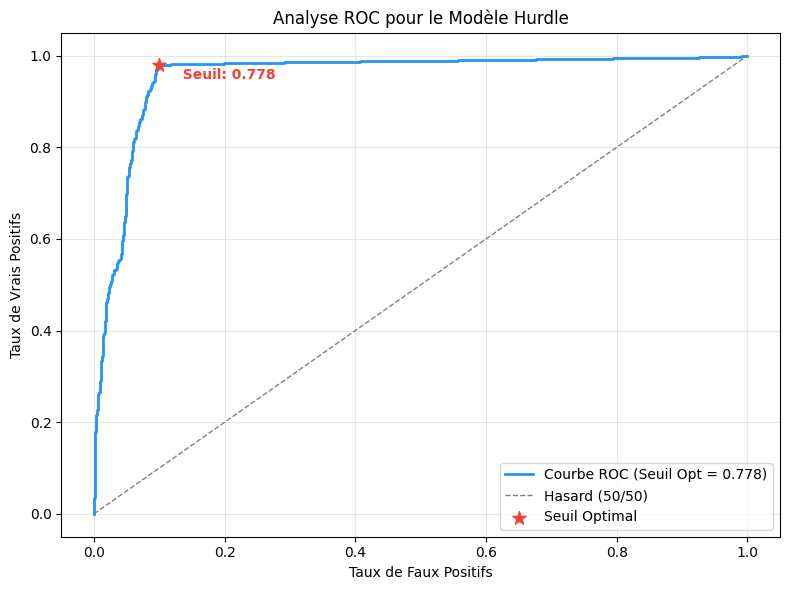

In [ ]:
import matplotlib.pyplot as plt

# --- Visualisation de la courbe ROC ---
fig, ax = plt.subplots(figsize=(8, 6))

# Tracer la courbe ROC
ax.plot(fpr, tpr, color='#2196F3', lw=2, label=f'Courbe ROC (Seuil Opt = {optimal_threshold:.3f})')

# Tracer la ligne de hasard (random guess)
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Hasard (50/50)')

# Placer le point optimal
ax.scatter(fpr[optimal_idx], tpr[optimal_idx], color='#F44336', s=100, zorder=5, 
           label='Seuil Optimal', marker='*')

# Annotations
ax.annotate(f'  Seuil: {optimal_threshold:.3f}', 
            (fpr[optimal_idx], tpr[optimal_idx]), 
            xytext=(10, -10), textcoords='offset points', fontsize=10, color='#F44336', weight='bold')

ax.set_xlabel('Taux de Faux Positifs')
ax.set_ylabel('Taux de Vrais Positifs')
ax.set_title('Analyse ROC pour le Modèle Hurdle')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve_hurdle.pdf', bbox_inches='tight')
plt.show()

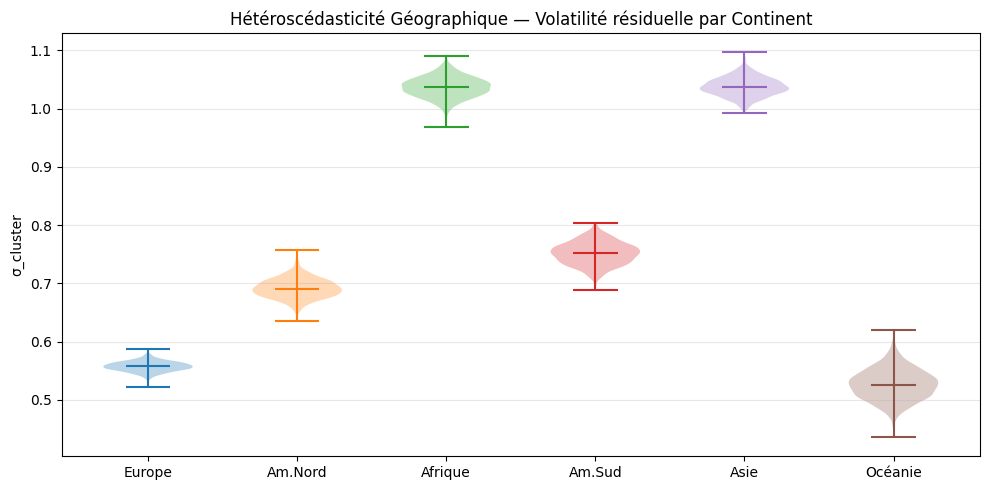

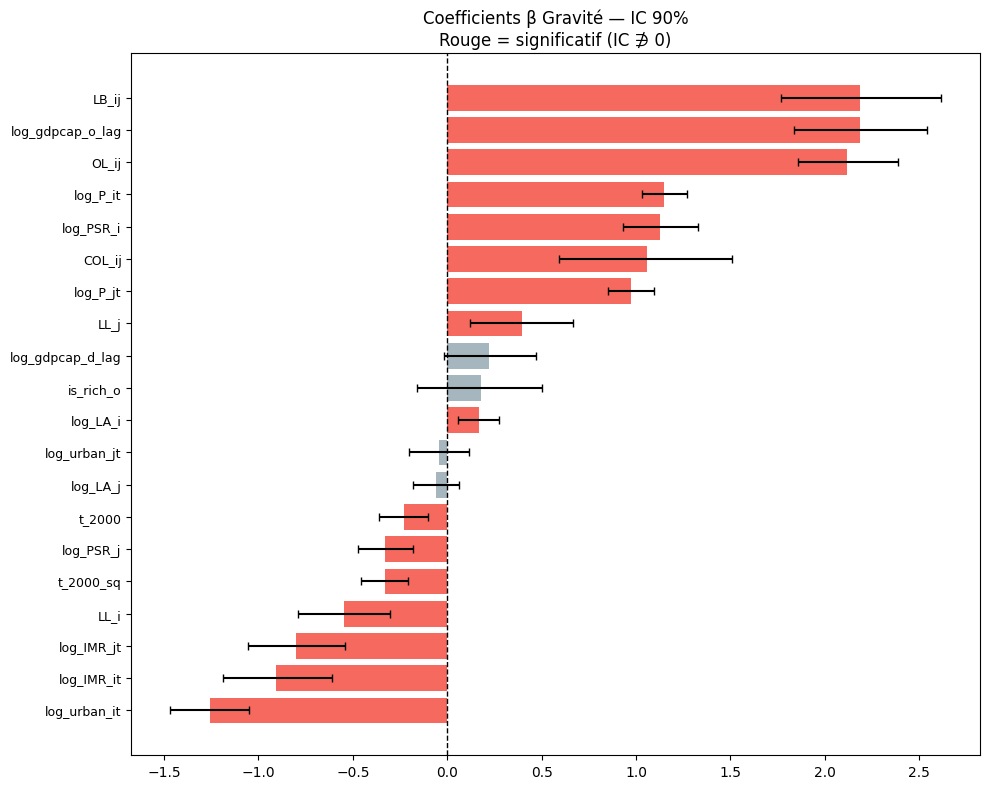

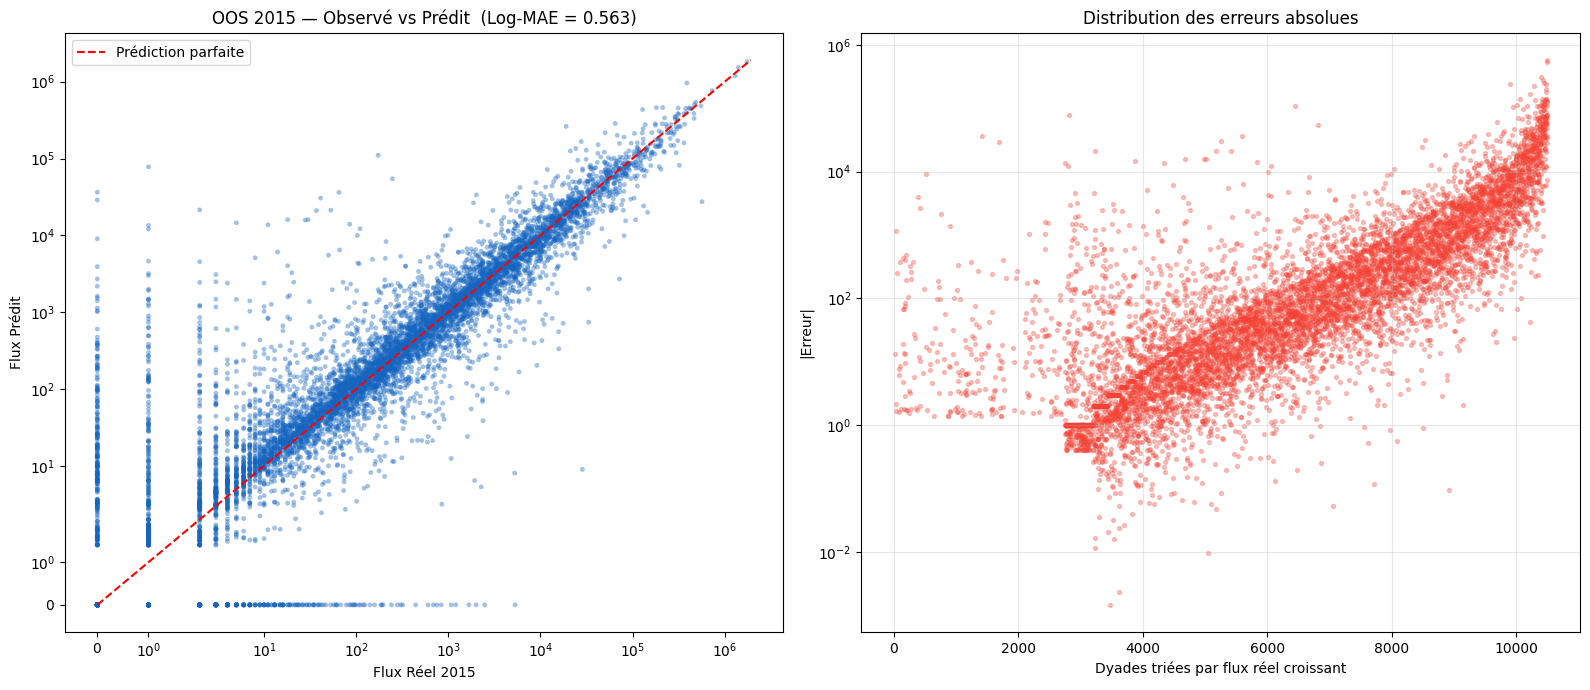

In [15]:
# Visualisations




CONTINENT_NAMES = {1:'Europe', 2:'Am.Nord', 3:'Afrique',
                   4:'Am.Sud', 5:'Asie', 6:'Océanie'}

fig, ax = plt.subplots(figsize=(10, 5))
sigma_draws = idata.posterior['sigma_cluster'].values  
for k in range(1, K_clusters + 1):
    draws_k = sigma_draws[..., k-1].flatten()
    ax.violinplot(draws_k, positions=[k], widths=0.6, showmedians=True)
ax.set_xticks(range(1, K_clusters + 1))
ax.set_xticklabels([CONTINENT_NAMES.get(k, f'C{k}') for k in range(1, K_clusters + 1)])
ax.set_ylabel("σ_cluster")
ax.set_title("Hétéroscédasticité Géographique — Volatilité résiduelle par Continent")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('variance_cluster.pdf', bbox_inches='tight')
plt.show()

beta_flat  = idata.posterior['beta_grav'].values.reshape(-1, K_grav)
beta_means = beta_flat.mean(axis=0)
beta_q05, beta_q95 = np.percentile(beta_flat, [5, 95], axis=0)
order = np.argsort(beta_means)

fig, ax = plt.subplots(figsize=(10, max(6, K_grav * 0.4)))
colors_coef = ['#F44336' if beta_q05[i] > 0 or beta_q95[i] < 0
               else '#90A4AE' for i in order]
ax.barh(range(K_grav), beta_means[order],
        xerr=[beta_means[order] - beta_q05[order],
              beta_q95[order]   - beta_means[order]],
        color=colors_coef, alpha=0.8, capsize=3)
ax.set_yticks(range(K_grav))
ax.set_yticklabels([X_VOL_COLS[i] for i in order], fontsize=9)
ax.axvline(0, color='black', lw=1, ls='--')
ax.set_title("Coefficients β Gravité — IC 90%\nRouge = significatif (IC ∌ 0)")
plt.tight_layout()
plt.savefig('gravity_coefficients.pdf', bbox_inches='tight') # ne pas enlever les variables non significatives. Elles pourraient le devenir pour 190 pays, c'est ce qu'on attend. 
plt.show()     # avec 190 pays, le modèle sera largement assez puissant pour detecter tous les effets. Sauf peut être les variables englobées par d'autres (par ex LB_ij capturé par le Hurdle et par D_ij)

# Variables politiques et de conflit à ajouter:                                                      
# UCDP/PRIO Armed Conflict Dataset
# Freedom House / Polity V
# Aucune modification dans Stan (K_v est déjà paramétrique) , juste merge puis 2 lignes Python. 
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.scatter(y_true, y_pred, alpha=0.4, s=12, color='#1565C0', edgecolors='none')
lim = [0, max(y_true.max(), y_pred.max()) * 1.05]
ax.plot(lim, lim, 'r--', lw=1.5, label='Prédiction parfaite')
ax.set_xscale('symlog')
ax.set_yscale('symlog')
ax.set_xlabel("Flux Réel 2015")
ax.set_ylabel("Flux Prédit")
ax.set_title(f"OOS 2015 — Observé vs Prédit  (Log-MAE = {log_mae:.3f})")
ax.legend()

ax2 = axes[1]
order_err = np.argsort(y_true)
ax2.scatter(range(len(y_true)), np.abs(y_true[order_err] - y_pred[order_err]),
            alpha=0.3, s=8, color='#F44336')
ax2.set_xlabel("Dyades triées par flux réel croissant")
ax2.set_ylabel("|Erreur|")
ax2.set_yscale('log')
ax2.set_title("Distribution des erreurs absolues")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_scatter.pdf', bbox_inches='tight')
plt.show()

In [ ]:
summary = fit.summary()

# Hyperparamètres globaux uniquement (lisible)
params_watch = [
    'alpha_global', 'tau_alpha', 
    'beta_lag_continent[1]', 'beta_lag_continent[2]', 'beta_lag_continent[3]',
    'beta_lag_continent[4]', 'beta_lag_continent[5]', 'beta_lag_continent[6]',
    'mu_intercept', 'tau_mu', 'phi_global_monitor',
    'sigma_global', 'tau_sigma', 'tau_phi',
    'sigma_cluster[1]', 'sigma_cluster[2]', 'sigma_cluster[3]',
    'sigma_cluster[4]', 'sigma_cluster[5]', 'sigma_cluster[6]',
]
# Filtre sur les params qui existent vraiment dans le summary
params_found = [p for p in params_watch if p in summary.index]
print(summary.loc[params_found, ['Mean', 'StdDev', '5%', '95%', 'R_hat', 'ESS_bulk']])

print(f"\nR_hat max (tous paramètres) : {summary['R_hat'].max():.4f}")
print(f"ESS_bulk min               : {summary['ESS_bulk'].min():.0f}")
print(f"Nb divergences             : {fit.divergences.sum()}")


                           Mean    StdDev        5%       95%     R_hat  \
alpha_global          -1.356040  0.067499 -1.467050 -1.241490  0.998331   
tau_alpha              0.059756  0.047545  0.004752  0.155347  1.004570   
beta_lag_continent[1]  8.003320  0.338393  7.489110  8.570950  1.001990   
beta_lag_continent[2]  4.637610  0.125205  4.426910  4.852970  1.001480   
beta_lag_continent[3]  4.001700  0.096372  3.838950  4.165950  1.002250   
beta_lag_continent[4]  5.531270  0.202325  5.201520  5.845710  1.001150   
beta_lag_continent[5]  4.535700  0.102196  4.375300  4.709160  1.000260   
beta_lag_continent[6]  6.462450  0.381347  5.871030  7.104130  0.998288   
mu_intercept           2.100360  0.194746  1.790760  2.415480  1.002080   
tau_mu                 0.136672  0.104969  0.007703  0.333353  1.003420   
phi_global_monitor     0.933309  0.002845  0.928791  0.937982  1.001350   
sigma_global           0.668894  0.196593  0.357322  0.995171  0.998270   
tau_sigma              0.

In [ ]:
beta_draws = fit.stan_variable('beta_grav')  # (n_draws, K_grav)
beta_means = beta_draws.mean(axis=0)
beta_q05   = np.percentile(beta_draws, 5,  axis=0)
beta_q95   = np.percentile(beta_draws, 95, axis=0)

print(f"{'Variable':<25} {'Moyenne':>10} {'IC 5%':>10} {'IC 95%':>10}  {'Significatif?':>14}")
print("-" * 65)
for j, col in enumerate(X_VOL_COLS):
    sig = "✓ OUI" if (beta_q05[j] > 0 or beta_q95[j] < 0) else "  non"
    print(f"{col:<25} {beta_means[j]:>10.3f} {beta_q05[j]:>10.3f} {beta_q95[j]:>10.3f}  {sig:>14}")

Variable                     Moyenne      IC 5%     IC 95%   Significatif?
-----------------------------------------------------------------
log_P_it                       1.202      1.042      1.365           ✓ OUI
log_P_jt                       0.890      0.701      1.068           ✓ OUI
log_PSR_i                      1.266      0.993      1.558           ✓ OUI
log_PSR_j                     -0.138     -0.372      0.105             non
log_IMR_it                    -0.864     -1.302     -0.443           ✓ OUI
log_IMR_jt                    -0.853     -1.199     -0.514           ✓ OUI
log_urban_it                  -1.555     -1.906     -1.238           ✓ OUI
log_urban_jt                  -0.218     -0.445      0.016             non
log_LA_i                       0.143     -0.001      0.298             non
log_LA_j                       0.056     -0.117      0.232             non
LL_i                          -1.840     -2.284     -1.423           ✓ OUI
LL_j                           1.6

Figure 1: le Graal, ce serait des formes étalées horizontalement, basses sur l'axe des Y (modèle sûr de lui + volatilité basse). 
Figure 2: 